Objective: To determine the minimum duration of ridership data required to obtain a stable and consistent ranking of metro stations, such that the ranking becomes invariant to short-term demand fluctuations caused by temporal events.

Assumption: It is assumed that the built environment (urban morphology) surrounding each station remains relatively constant over the study period. Therefore, station-level ridership—and its relative ranking—is primarily driven by these stable structural factors rather than short-term temporal variations.

### Hyderabad Metro Stops Monthly Demand Stability


--- Consecutive Stability ---
Months: 4, Spearman Corr: 0.9992
Months: 5, Spearman Corr: 0.9987
Months: 6, Spearman Corr: 0.9982
Months: 7, Spearman Corr: 0.9960
Months: 8, Spearman Corr: 0.9983
Months: 9, Spearman Corr: 0.9991
Months: 10, Spearman Corr: 0.9990
Months: 11, Spearman Corr: 0.9998
Months: 12, Spearman Corr: 0.9994
Months: 13, Spearman Corr: 0.9969
Months: 14, Spearman Corr: 0.9968
Months: 15, Spearman Corr: 0.9996
Months: 16, Spearman Corr: 0.9995
Months: 17, Spearman Corr: 0.9999
Months: 18, Spearman Corr: 0.9999
Months: 19, Spearman Corr: 0.9996
Months: 20, Spearman Corr: 0.9997
Months: 21, Spearman Corr: 0.9994

✅ Stable (incremental) at ~4 months


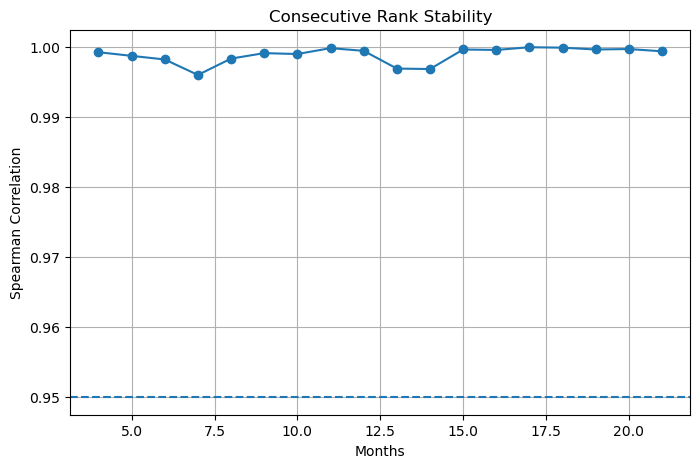


--- Stability vs Full Ranking ---
Months: 3, Corr vs Full: 0.9524
Months: 4, Corr vs Full: 0.9541
Months: 5, Corr vs Full: 0.9574
Months: 6, Corr vs Full: 0.9693
Months: 7, Corr vs Full: 0.9831
Months: 8, Corr vs Full: 0.9885
Months: 9, Corr vs Full: 0.9905
Months: 10, Corr vs Full: 0.9925
Months: 11, Corr vs Full: 0.9933
Months: 12, Corr vs Full: 0.9940
Months: 13, Corr vs Full: 0.9973
Months: 14, Corr vs Full: 0.9963
Months: 15, Corr vs Full: 0.9968
Months: 16, Corr vs Full: 0.9979
Months: 17, Corr vs Full: 0.9980
Months: 18, Corr vs Full: 0.9982
Months: 19, Corr vs Full: 0.9987
Months: 20, Corr vs Full: 0.9994
Months: 21, Corr vs Full: 1.0000


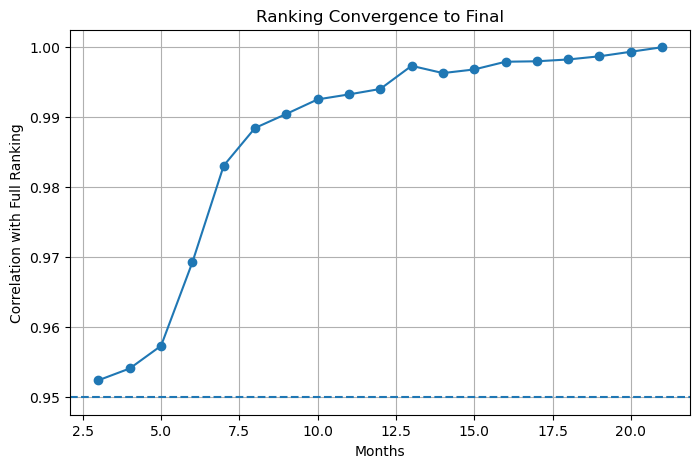


--- Rank Error (Final Window) ---
count    57.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

--- Station-wise Stability ---
              MAD   Rank_STD  Max_Shift
Station                                
AME(C1)  8.578947  10.730620       29.0
SCR      5.473684   5.591347       13.0
GAB      2.894737   3.494356       11.0
HSG      3.052632   2.758294        6.0
MUN      2.736842   2.735942        8.0
STD      2.263158   2.243900        6.0
MSB      2.000000   2.115109        6.0
RDG      2.368421   2.113726        8.0
DSN      1.736842   2.050531        5.0
VOM      1.473684   1.806421        5.0
NAM      0.894737   1.609548        5.0
MET      2.473684   1.540866        5.0
OMC      1.000000   1.464991        4.0
NAR      1.210526   1.342077        4.0
PAR      1.052632   1.290994        4.0


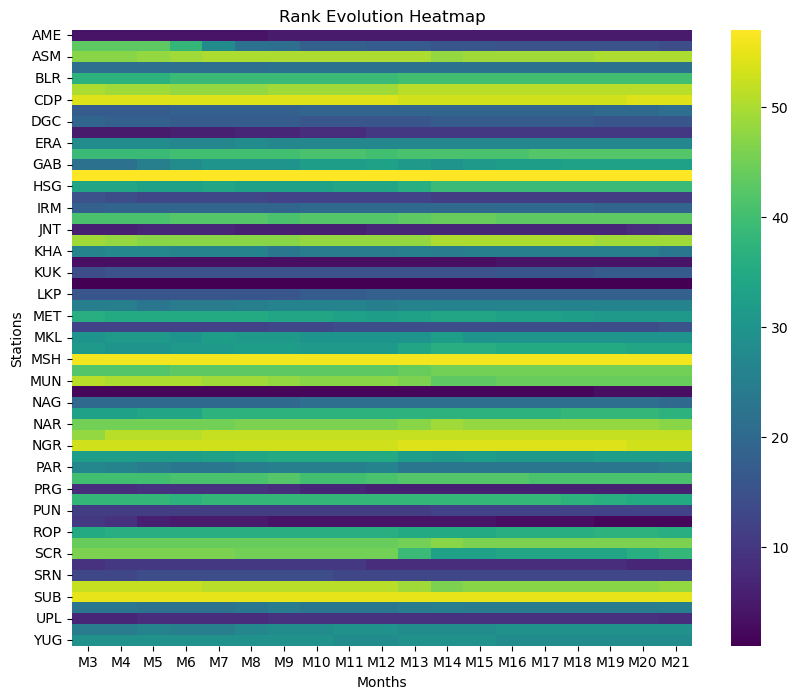


--- Bootstrap Rank Confidence Intervals ---
         Rank_mean  Rank_std  Rank_p5  Rank_p95  CI_width
Station                                                  
LBN          1.120  0.325124      1.0       2.0       1.0
RDG          2.090  0.591819      1.0       3.0       2.0
MYP          2.805  0.398916      2.0       3.0       1.0
KPH          3.985  0.121613      4.0       4.0       0.0
AME          5.240  0.593930      5.0       7.0       2.0
PRG          5.923  0.505298      5.0       7.0       2.0
SEC          7.423  0.909339      6.0       9.0       3.0
UPL          8.188  0.665657      7.0       9.0       2.0
JNT          8.227  0.881049      7.0       9.0       2.0
DSN         10.008  0.099729     10.0      10.0       0.0
HTC         11.072  0.291378     11.0      12.0       1.0
PUN         12.171  0.605083     11.0      13.0       2.0
SRN         12.822  0.456645     12.0      13.0       1.0
MGB         14.618  0.656130     14.0      16.0       2.0
AME(C1)     14.749  1.21716

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- LOAD DATA ----------------
file_path = r"C:\Users\Anurodh\Downloads\Hyderabad_Station_monthwise_demand - Sheet1.csv"
df = pd.read_csv(file_path)

# Set station as index
df = df.set_index("Station")

# ---------------- FIX COLUMN ORDER ----------------
def parse_col(col):
    return pd.to_datetime(col, format="%b%y")

df = df.reindex(sorted(df.columns, key=parse_col), axis=1)

# ---------------- PARAMETERS ----------------
window_sizes = range(3, df.shape[1] + 1)
threshold = 0.95

rankings = {}
correlations = []

# ---------------- COMPUTE RANKINGS ----------------
for w in window_sizes:
    subset = df.iloc[:, :w]
    mean_ridership = subset.mean(axis=1)
    rank = mean_ridership.rank(ascending=False, method='average')
    rankings[w] = rank

# ---------------- CONSECUTIVE STABILITY ----------------
print("\n--- Consecutive Stability ---")
stable_month = None

for i in range(1, len(window_sizes)):
    w1 = window_sizes[i-1]
    w2 = window_sizes[i]
    
    r1 = rankings[w1]
    r2 = rankings[w2]
    
    corr, _ = spearmanr(r1, r2)
    correlations.append((w2, corr))
    
    print(f"Months: {w2}, Spearman Corr: {corr:.4f}")
    
    if corr >= threshold and stable_month is None:
        stable_month = w2

if stable_month:
    print(f"\n✅ Stable (incremental) at ~{stable_month} months")
else:
    print("\n⚠️ Stability threshold not reached")

# ---------------- PLOT: CONSECUTIVE ----------------
months = [x[0] for x in correlations]
corr_vals = [x[1] for x in correlations]

plt.figure(figsize=(8,5))
plt.plot(months, corr_vals, marker='o')
plt.axhline(y=threshold, linestyle='--')
plt.xlabel("Months")
plt.ylabel("Spearman Correlation")
plt.title("Consecutive Rank Stability")
plt.grid()
plt.show()

# ---------------- FULL RANK COMPARISON ----------------
print("\n--- Stability vs Full Ranking ---")

full_rank = df.mean(axis=1).rank(ascending=False)
results = []

for w in window_sizes:
    partial = df.iloc[:, :w].mean(axis=1).rank(ascending=False)
    corr, _ = spearmanr(partial, full_rank)
    results.append((w, corr))
    
    print(f"Months: {w}, Corr vs Full: {corr:.4f}")

# ---------------- PLOT: VS FULL ----------------
months_full = [x[0] for x in results]
corr_full = [x[1] for x in results]

plt.figure(figsize=(8,5))
plt.plot(months_full, corr_full, marker='o')
plt.axhline(y=threshold, linestyle='--')
plt.xlabel("Months")
plt.ylabel("Correlation with Full Ranking")
plt.title("Ranking Convergence to Final")
plt.grid()
plt.show()

# ---------------- RANK ERROR ----------------
print("\n--- Rank Error (Final Window) ---")

final_partial = df.iloc[:, :window_sizes[-1]].mean(axis=1).rank(ascending=False)
rank_error = (final_partial - full_rank).abs()

print(rank_error.describe())

# ---------------- RANK STABILITY PER STATION ----------------
print("\n--- Station-wise Stability ---")

rank_matrix = pd.DataFrame(index=df.index)

for w in window_sizes:
    rank_matrix[f"M{w}"] = rankings[w]

stability = pd.DataFrame(index=df.index)

stability["MAD"] = (rank_matrix.sub(full_rank, axis=0)).abs().mean(axis=1)
stability["Rank_STD"] = rank_matrix.std(axis=1)
stability["Max_Shift"] = rank_matrix.max(axis=1) - rank_matrix.min(axis=1)

stability = stability.sort_values("Rank_STD", ascending=False)

print(stability.head(15))

# ---------------- HEATMAP ----------------
plt.figure(figsize=(10,8))
sns.heatmap(rank_matrix, cmap="viridis")
plt.title("Rank Evolution Heatmap")
plt.xlabel("Months")
plt.ylabel("Stations")
plt.show()

print("\n--- Bootstrap Rank Confidence Intervals ---")

n_boot = 1000
stations = df.index

boot_list = []  # collect all ranks here

for i in range(n_boot):
    sampled_cols = np.random.choice(df.columns, size=len(df.columns), replace=True)
    sample_df = df[sampled_cols]
    
    mean_vals = sample_df.mean(axis=1)
    rank = mean_vals.rank(ascending=False)
    
    boot_list.append(rank)

# Combine all at once (fast, no fragmentation)
boot_ranks = pd.concat(boot_list, axis=1)
boot_ranks.columns = [f"B{i}" for i in range(n_boot)]

# ---------------- CONFIDENCE INTERVALS ----------------
ci = pd.DataFrame(index=stations)

ci["Rank_mean"] = boot_ranks.mean(axis=1)
ci["Rank_std"] = boot_ranks.std(axis=1)
ci["Rank_p5"] = boot_ranks.quantile(0.05, axis=1)
ci["Rank_p95"] = boot_ranks.quantile(0.95, axis=1)

ci["CI_width"] = ci["Rank_p95"] - ci["Rank_p5"]

ci = ci.sort_values("Rank_mean")

print(ci.head(15))

### Chennai Metro Stops Daily Demand Stability

Data shape: (43, 12)

--- Rolling 3-Day Stability ---
Window ending Day 4, Corr: 0.9707
Window ending Day 5, Corr: 0.9842
Window ending Day 6, Corr: 0.9757
Window ending Day 7, Corr: 0.9906
Window ending Day 8, Corr: 0.9986
Window ending Day 9, Corr: 0.9976
Window ending Day 10, Corr: 0.9899
Window ending Day 11, Corr: 0.9713
Window ending Day 12, Corr: 0.9950


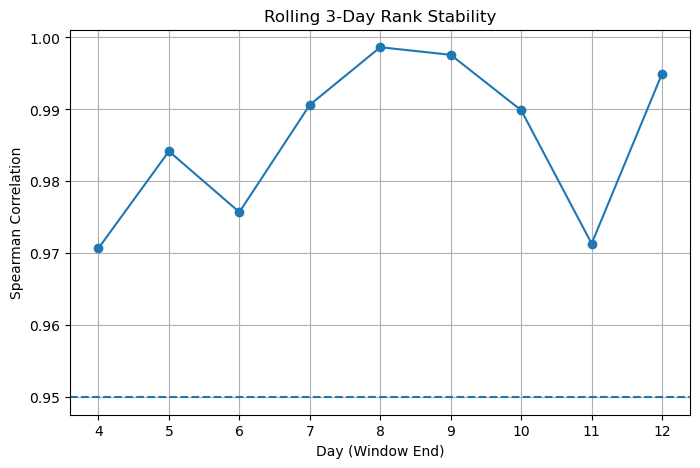


--- Stability vs Full Ranking ---
Day 3, Corr vs Full: 0.9955
Day 4, Corr vs Full: 0.9672
Day 5, Corr vs Full: 0.9686
Day 6, Corr vs Full: 0.9950
Day 7, Corr vs Full: 0.9924
Day 8, Corr vs Full: 0.9909
Day 9, Corr vs Full: 0.9905
Day 10, Corr vs Full: 0.9938
Day 11, Corr vs Full: 0.9643
Day 12, Corr vs Full: 0.9680

--- Station-wise Stability ---
                              MAD  Rank_STD  Max_Shift
Station                                               
AG-DMS                       5.00  5.940445       14.0
NANDANAM                     4.50  4.931757       12.0
ALANDUR                      4.00  4.812022       14.0
SAIDAPET                     3.90  4.110961       11.0
CMBT                         2.90  3.478505        9.0
EGMORE                       2.60  3.011091        8.0
THIRUVOTRIYUR THERADI METRO  2.15  2.773385        7.0
ANNA NAGAR TOWER             2.20  2.335713        6.0
ALANDUR                      1.60  2.221111        7.0
THOUSAND LIGHT               1.90  2.213594  

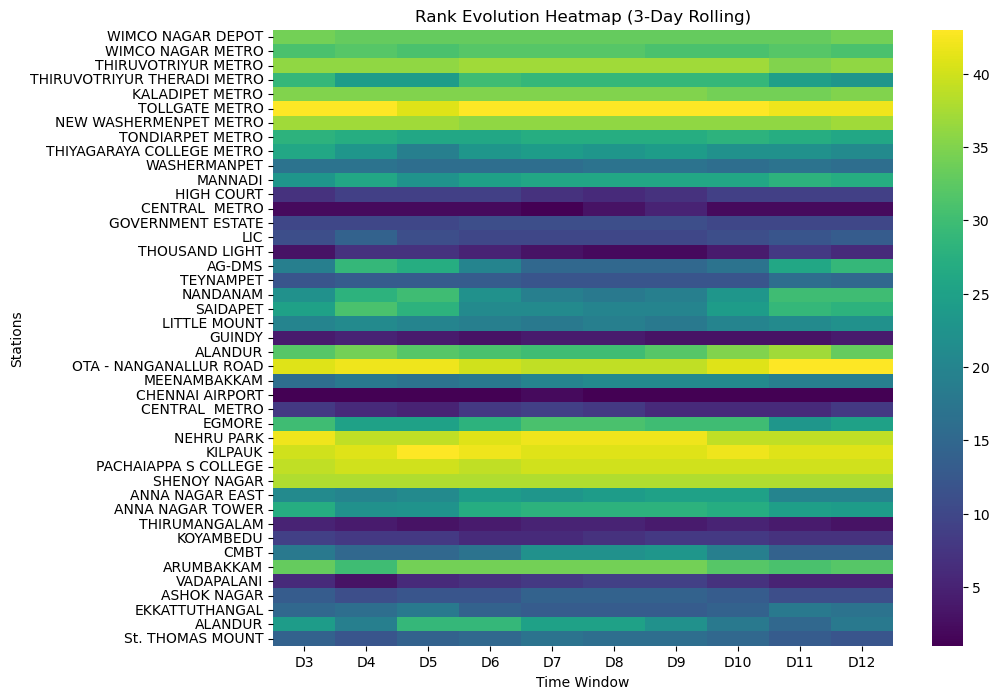


--- Bootstrap Rank Confidence Intervals ---
                   Rank_mean  Rank_std  Rank_p5  Rank_p95  CI_width
Station                                                            
CHENNAI AIRPORT        1.004  0.063182     1.00      1.00      0.00
CENTRAL  METRO         1.998  0.077511     2.00      2.00      0.00
GUINDY                 3.418  0.521363     3.00      4.00      1.00
THOUSAND LIGHT         4.346  1.110293     3.00      6.00      3.00
THIRUMANGALAM          4.392  0.680634     3.00      5.00      2.00
VADAPALANI             6.334  0.927450     5.00      8.00      3.00
KOYAMBEDU              7.416  0.654064     6.00      8.00      2.00
CENTRAL  METRO         7.524  0.993679     6.00      9.00      3.00
HIGH COURT             8.568  0.871145     6.00      9.00      3.00
GOVERNMENT ESTATE     10.226  0.418658    10.00     11.00      1.00
LIC                   10.814  0.509827    10.00     11.00      1.00
TEYNAMPET             12.272  0.637832    12.00     13.05      1.05
ASH

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- LOAD EXCEL ----------------
file_path = r"C:\Users\Anurodh\Downloads\Chennai_Station_Total_Passengers.xlsx"

xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names  # each sheet = one day

# ---------------- BUILD STATION x DAY MATRIX ----------------
df_list = []

for sheet in sheet_names:
    temp = pd.read_excel(file_path, sheet_name=sheet)
    
    temp = temp[["Station", "Total_Passengers"]].copy()
    temp = temp.set_index("Station")
    
    temp.columns = [sheet]
    df_list.append(temp)

df = pd.concat(df_list, axis=1)

# Fill missing stations
df = df.fillna(0)

# Try sorting columns chronologically
try:
    df = df.reindex(sorted(df.columns, key=lambda x: pd.to_datetime(x, format="%d_%b")), axis=1)
except:
    print("⚠️ Could not parse sheet names as dates — using original order")

print("Data shape:", df.shape)

# ---------------- PARAMETERS ----------------
window_size = 3
threshold = 0.95

# ---------------- ROLLING 3-DAY RANKINGS ----------------
rolling_rankings = []
rolling_days = []

for i in range(window_size, df.shape[1] + 1):
    subset = df.iloc[:, i-window_size:i]
    
    mean_ridership = subset.mean(axis=1)
    rank = mean_ridership.rank(ascending=False, method='average')
    
    rolling_rankings.append(rank)
    rolling_days.append(i)

# ---------------- STABILITY BETWEEN WINDOWS ----------------
print("\n--- Rolling 3-Day Stability ---")

rolling_corr = []

for i in range(1, len(rolling_rankings)):
    r1 = rolling_rankings[i-1]
    r2 = rolling_rankings[i]
    
    corr, _ = spearmanr(r1, r2)
    rolling_corr.append(corr)
    
    print(f"Window ending Day {rolling_days[i]}, Corr: {corr:.4f}")

# ---------------- PLOT ----------------
plt.figure(figsize=(8,5))
plt.plot(rolling_days[1:], rolling_corr, marker='o')
plt.axhline(y=threshold, linestyle='--')
plt.xlabel("Day (Window End)")
plt.ylabel("Spearman Correlation")
plt.title("Rolling 3-Day Rank Stability")
plt.grid()
plt.show()

# ---------------- FULL RANK COMPARISON ----------------
print("\n--- Stability vs Full Ranking ---")

full_rank = df.mean(axis=1).rank(ascending=False)

results = []

for i, day in enumerate(rolling_days):
    partial_rank = rolling_rankings[i]
    corr, _ = spearmanr(partial_rank, full_rank)
    
    results.append((day, corr))
    print(f"Day {day}, Corr vs Full: {corr:.4f}")

# ---------------- STATION-WISE STABILITY ----------------
print("\n--- Station-wise Stability ---")

rank_matrix = pd.concat(rolling_rankings, axis=1)
rank_matrix.columns = [f"D{d}" for d in rolling_days]

stability = pd.DataFrame(index=df.index)

stability["MAD"] = (rank_matrix.sub(full_rank, axis=0)).abs().mean(axis=1)
stability["Rank_STD"] = rank_matrix.std(axis=1)
stability["Max_Shift"] = rank_matrix.max(axis=1) - rank_matrix.min(axis=1)

stability = stability.sort_values("Rank_STD", ascending=False)

print(stability.head(15))

# ---------------- HEATMAP ----------------
plt.figure(figsize=(10,8))
sns.heatmap(rank_matrix, cmap="viridis")
plt.title("Rank Evolution Heatmap (3-Day Rolling)")
plt.xlabel("Time Window")
plt.ylabel("Stations")
plt.show()

# ---------------- BOOTSTRAP CONFIDENCE INTERVALS ----------------
print("\n--- Bootstrap Rank Confidence Intervals ---")

n_boot = 500
boot_list = []

for i in range(n_boot):
    sampled_cols = np.random.choice(df.columns, size=len(df.columns), replace=True)
    sample_df = df[sampled_cols]
    
    mean_vals = sample_df.mean(axis=1)
    rank = mean_vals.rank(ascending=False)
    
    boot_list.append(rank)

boot_ranks = pd.concat(boot_list, axis=1)

ci = pd.DataFrame(index=df.index)

ci["Rank_mean"] = boot_ranks.mean(axis=1)
ci["Rank_std"] = boot_ranks.std(axis=1)
ci["Rank_p5"] = boot_ranks.quantile(0.05, axis=1)
ci["Rank_p95"] = boot_ranks.quantile(0.95, axis=1)
ci["CI_width"] = ci["Rank_p95"] - ci["Rank_p5"]

ci = ci.sort_values("Rank_mean")

print(ci.head(15))

### Bengaluru Metro Stops Daily Demand Stability

Data shape: (83, 17)

--- Rolling 3-Day Stability ---
Window ending 2025-08-05, Corr: 0.9683
Window ending 2025-08-06, Corr: 0.9589
Window ending 2025-08-07, Corr: 0.9923
Window ending 2025-08-08, Corr: 0.9924
Window ending 2025-08-09, Corr: 0.9412
Window ending 2025-08-10, Corr: 0.9234
Window ending 2025-08-11, Corr: 0.8423
Window ending 2025-08-12, Corr: 0.9337
Window ending 2025-08-13, Corr: 0.9747
Window ending 2025-08-14, Corr: 0.9966
Window ending 2025-08-15, Corr: 0.9707
Window ending 2025-08-16, Corr: 0.9734
Window ending 2025-08-17, Corr: 0.9607
Window ending 2025-08-18, Corr: 0.9618


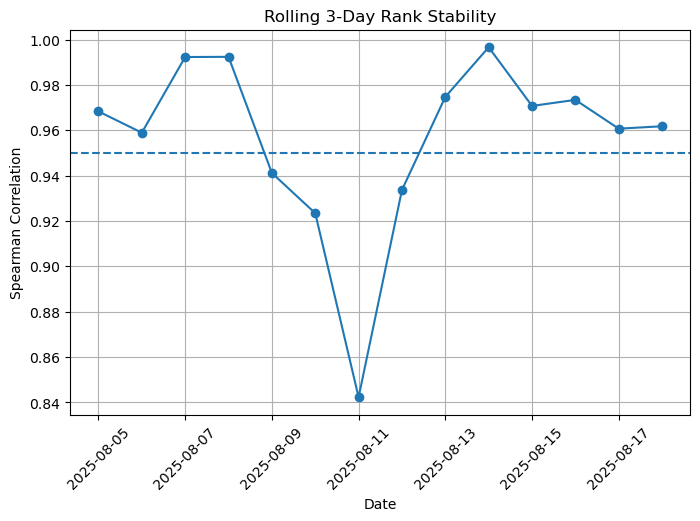


--- Stability vs Full Ranking ---
2025-08-04, Corr vs Full: 0.8303
2025-08-05, Corr vs Full: 0.8455
2025-08-06, Corr vs Full: 0.8536
2025-08-07, Corr vs Full: 0.8422
2025-08-08, Corr vs Full: 0.8551
2025-08-09, Corr vs Full: 0.8397
2025-08-10, Corr vs Full: 0.7741
2025-08-11, Corr vs Full: 0.9659
2025-08-12, Corr vs Full: 0.9718
2025-08-13, Corr vs Full: 0.9234
2025-08-14, Corr vs Full: 0.9264
2025-08-15, Corr vs Full: 0.9602
2025-08-16, Corr vs Full: 0.9500
2025-08-17, Corr vs Full: 0.8775
2025-08-18, Corr vs Full: 0.9293

--- Station-wise Stability ---
                                   MAD   Rank_STD  Max_Shift
station                                                     
310-Beratena Agrahara        24.133333  25.603571       56.0
38-Singasandra               22.866667  24.318913       53.0
133-Sri Sathya Sai Hospital  19.266667  22.109683       62.0
31-Ragigudda                 21.000000  22.068724       51.0
134-Pattandur Agrahara       17.400000  20.786213       63.0
36-Hongasan

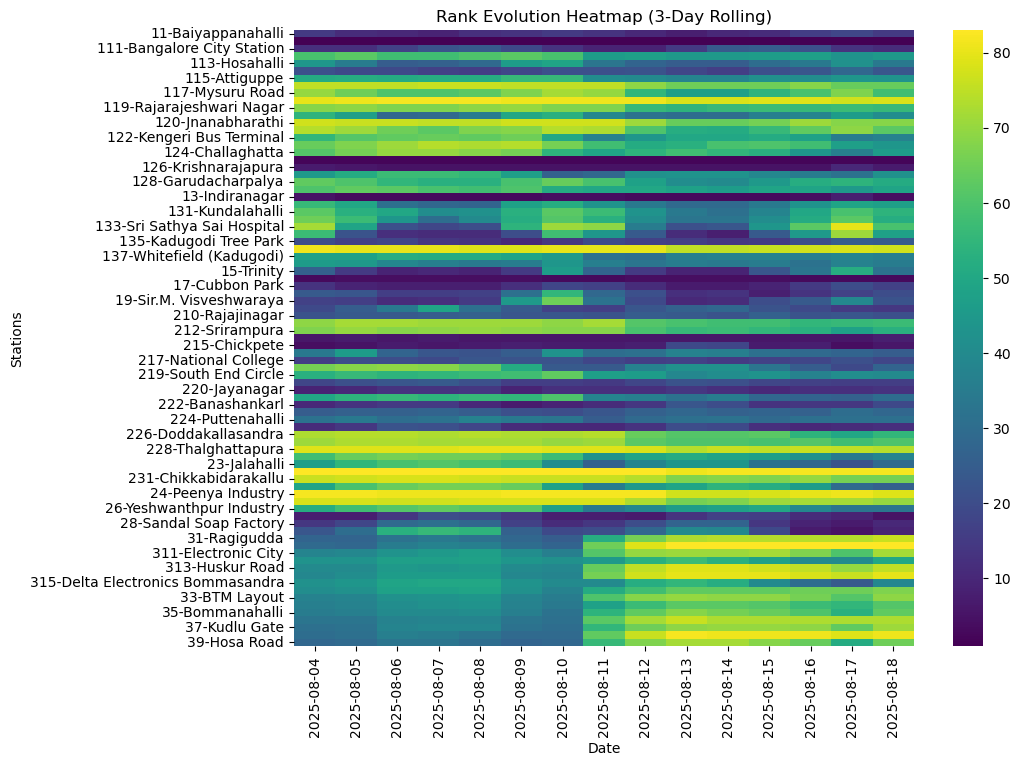


--- Bootstrap Rank Confidence Intervals ---
                                Rank_mean  Rank_std  Rank_p5  Rank_p95  \
station                                                                  
110-Kempegowda                      1.000  0.000000      1.0       1.0   
125-Benniganahalli                  2.000  0.000000      2.0       2.0   
13-Indiranagar                      3.396  0.505663      3.0       4.0   
16-MG Road                          3.612  0.487783      3.0       4.0   
126-Krishnarajapura                 5.168  0.473523      5.0       6.0   
213-Mantri Square Sampige Road      6.304  0.469067      6.0       7.0   
215-Chickpete                       6.648  0.955994      5.0       8.0   
27-Yeshwanthpur                     8.290  1.060259      7.0      11.0   
220-Jayanagar                       9.828  1.112155      9.0      12.0   
17-Cubbon Park                     10.844  2.237337      8.0      15.0   

                                CI_width  
station                

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- LOAD DATA ----------------
file_path = r"C:\Users\Anurodh\Downloads\Bengaluru_Stops_Ridership - Sheet1.csv"  # or .xlsx

df = pd.read_csv(file_path)  # use read_excel if needed

# ---------------- FORMAT ----------------
# Set station as index
df = df.set_index("station")

# Clean column names (remove suffix)
df.columns = [col.replace("_total_ridership", "") for col in df.columns]

# Convert to datetime and sort
df.columns = pd.to_datetime(df.columns)
df = df.sort_index(axis=1)

print("Data shape:", df.shape)

# ---------------- PARAMETERS ----------------
window_size = 3
threshold = 0.95

# ---------------- ROLLING 3-DAY RANKINGS ----------------
rolling_rankings = []
rolling_days = []

for i in range(window_size, df.shape[1] + 1):
    subset = df.iloc[:, i-window_size:i]
    
    mean_ridership = subset.mean(axis=1)
    rank = mean_ridership.rank(ascending=False, method='average')
    
    rolling_rankings.append(rank)
    rolling_days.append(df.columns[i-1])  # actual date

# ---------------- STABILITY BETWEEN WINDOWS ----------------
print("\n--- Rolling 3-Day Stability ---")

rolling_corr = []

for i in range(1, len(rolling_rankings)):
    r1 = rolling_rankings[i-1]
    r2 = rolling_rankings[i]
    
    corr, _ = spearmanr(r1, r2)
    rolling_corr.append(corr)
    
    print(f"Window ending {rolling_days[i].date()}, Corr: {corr:.4f}")

# ---------------- PLOT ----------------
plt.figure(figsize=(8,5))
plt.plot(rolling_days[1:], rolling_corr, marker='o')
plt.axhline(y=threshold, linestyle='--')
plt.xlabel("Date")
plt.ylabel("Spearman Correlation")
plt.title("Rolling 3-Day Rank Stability")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# ---------------- FULL RANK COMPARISON ----------------
print("\n--- Stability vs Full Ranking ---")

full_rank = df.mean(axis=1).rank(ascending=False)

results = []

for i, date in enumerate(rolling_days):
    partial_rank = rolling_rankings[i]
    corr, _ = spearmanr(partial_rank, full_rank)
    
    results.append((date, corr))
    print(f"{date.date()}, Corr vs Full: {corr:.4f}")

# ---------------- STATION-WISE STABILITY ----------------
print("\n--- Station-wise Stability ---")

rank_matrix = pd.concat(rolling_rankings, axis=1)
rank_matrix.columns = [str(d.date()) for d in rolling_days]

stability = pd.DataFrame(index=df.index)

stability["MAD"] = (rank_matrix.sub(full_rank, axis=0)).abs().mean(axis=1)
stability["Rank_STD"] = rank_matrix.std(axis=1)
stability["Max_Shift"] = rank_matrix.max(axis=1) - rank_matrix.min(axis=1)

stability = stability.sort_values("Rank_STD", ascending=False)

print(stability.head(10))

# ---------------- HEATMAP ----------------
plt.figure(figsize=(10,8))
sns.heatmap(rank_matrix, cmap="viridis")
plt.title("Rank Evolution Heatmap (3-Day Rolling)")
plt.xlabel("Date")
plt.ylabel("Stations")
plt.show()

# ---------------- BOOTSTRAP CONFIDENCE INTERVALS ----------------
print("\n--- Bootstrap Rank Confidence Intervals ---")

n_boot = 500
boot_list = []

for i in range(n_boot):
    sampled_cols = np.random.choice(df.columns, size=len(df.columns), replace=True)
    sample_df = df[sampled_cols]
    
    mean_vals = sample_df.mean(axis=1)
    rank = mean_vals.rank(ascending=False)
    
    boot_list.append(rank)

boot_ranks = pd.concat(boot_list, axis=1)

ci = pd.DataFrame(index=df.index)

ci["Rank_mean"] = boot_ranks.mean(axis=1)
ci["Rank_std"] = boot_ranks.std(axis=1)
ci["Rank_p5"] = boot_ranks.quantile(0.05, axis=1)
ci["Rank_p95"] = boot_ranks.quantile(0.95, axis=1)
ci["CI_width"] = ci["Rank_p95"] - ci["Rank_p5"]

ci = ci.sort_values("Rank_mean")

print(ci.head(10))

### Kochi Metro Stops Daily Demand Stability

Data shape: (23, 3)

--- Rank Correlation ---
2015 vs 2020: 0.9785
2020 vs 2025: 0.7579
2015 vs 2025: 0.7922

--- Biggest Improvements (2015 → 2025) ---
              2015  2020  2025  Change_15_20  Change_20_25  Change_15_25
Station_Name                                                            
JLN Stadium   15.0  15.0   4.0           0.0          11.0          11.0
Ambattukavu   22.0  22.0  15.0           0.0           7.0           7.0
Companypadi   17.5  20.0  13.0          -2.5           7.0           4.5
Apollo        16.0  19.0  12.0          -3.0           7.0           4.0
Palarivattom  12.0  11.0   8.0           1.0           3.0           4.0

--- Biggest Declines (2015 → 2025) ---
                  2015  2020  2025  Change_15_20  Change_20_25  Change_15_25
Station_Name                                                                
Kalamassery       10.0  10.0  18.0           0.0          -8.0          -8.0
Maharaja College   3.0   3.0  10.0           0.0          -7.0   

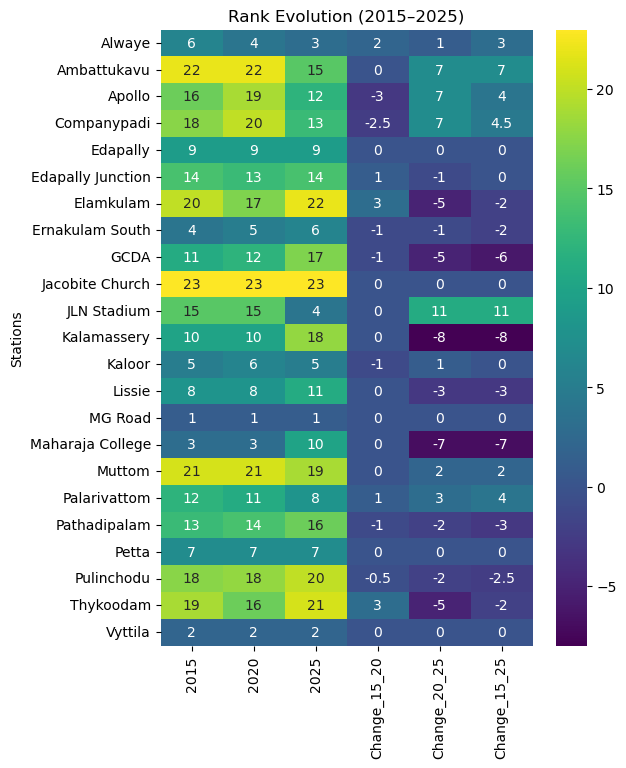


--- Highest Growth Stations (%) ---
              Growth_15_25
Station_Name              
Ambattukavu     421.400000
JLN Stadium     380.955260
Companypadi     324.929577
Muttom          294.736842
Apollo          247.947948

--- Rank Stability (Proxy CI) ---
                  Mean_Rank   Rank_STD
Station_Name                          
Maharaja College   0.333333   6.562520
MG Road            0.500000   0.547723
Vyttila            1.000000   1.095445
Ernakulam South    1.833333   3.544949
Kaloor             2.666667   3.011091
Alwaye             3.166667   1.722401
Petta              3.500000   3.834058
Lissie             3.500000   6.220932
Kalamassery        3.666667  10.689559
Edapally           4.500000   4.929503


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- LOAD DATA ----------------
file_path = r"C:\Users\Anurodh\Downloads\Kochi Peak Hour Demand_ - Sheet1.csv"

df = pd.read_csv(file_path)

# ---------------- FORMAT ----------------
df = df.set_index("Station_Name")

# Rename columns for convenience
df.columns = ["Y2015", "Y2020", "Y2025"]

print("Data shape:", df.shape)

# ---------------- RANKINGS ----------------
rank_2015 = df["Y2015"].rank(ascending=False)
rank_2020 = df["Y2020"].rank(ascending=False)
rank_2025 = df["Y2025"].rank(ascending=False)

rank_df = pd.DataFrame({
    "2015": rank_2015,
    "2020": rank_2020,
    "2025": rank_2025
})

# ---------------- CORRELATION (STABILITY) ----------------
print("\n--- Rank Correlation ---")

corr_15_20, _ = spearmanr(rank_2015, rank_2020)
corr_20_25, _ = spearmanr(rank_2020, rank_2025)
corr_15_25, _ = spearmanr(rank_2015, rank_2025)

print(f"2015 vs 2020: {corr_15_20:.4f}")
print(f"2020 vs 2025: {corr_20_25:.4f}")
print(f"2015 vs 2025: {corr_15_25:.4f}")

# ---------------- RANK CHANGE ----------------
rank_df["Change_15_20"] = rank_df["2015"] - rank_df["2020"]
rank_df["Change_20_25"] = rank_df["2020"] - rank_df["2025"]
rank_df["Change_15_25"] = rank_df["2015"] - rank_df["2025"]

print("\n--- Biggest Improvements (2015 → 2025) ---")
print(rank_df.sort_values("Change_15_25", ascending=False).head(5))

print("\n--- Biggest Declines (2015 → 2025) ---")
print(rank_df.sort_values("Change_15_25").head(5))

# ---------------- STABILITY METRICS ----------------
stability = pd.DataFrame(index=df.index)

stability["Rank_STD"] = rank_df.std(axis=1)
stability["Max_Shift"] = rank_df.max(axis=1) - rank_df.min(axis=1)

stability = stability.sort_values("Rank_STD", ascending=False)

print("\n--- Most Unstable Stations ---")
print(stability.head(5))

# ---------------- HEATMAP ----------------
plt.figure(figsize=(6,8))
sns.heatmap(rank_df, annot=True, cmap="viridis", cbar=True)
plt.title("Rank Evolution (2015–2025)")
plt.ylabel("Stations")
plt.show()

# ---------------- DEMAND GROWTH ----------------
growth = pd.DataFrame(index=df.index)

growth["Growth_15_25"] = (df["Y2025"] - df["Y2015"]) / df["Y2015"] * 100

growth = growth.sort_values("Growth_15_25", ascending=False)

print("\n--- Highest Growth Stations (%) ---")
print(growth.head(5))

# ---------------- SIMPLE CONFIDENCE PROXY ----------------
# (Since only 3 years, bootstrap is weak → use variability)

ci_proxy = pd.DataFrame(index=df.index)

ci_proxy["Mean_Rank"] = rank_df.mean(axis=1)
ci_proxy["Rank_STD"] = rank_df.std(axis=1)

ci_proxy = ci_proxy.sort_values("Mean_Rank")

print("\n--- Rank Stability (Proxy CI) ---")
print(ci_proxy.head(10))